# FMCG Product Classifier

# Step 1- Installing and Importing required libraries

In [1]:
!pip install timm --quiet

import os, random, json, zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.datasets import Food101

import timm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using: {device}')
if device == 'cpu':
    print('Switch to GPU: Runtime → Change runtime type → T4 GPU')

Using: cuda


## Step 2 — Download Food101 (PyTorch built in dataset)

In [2]:
train_data = Food101(root='/content/food101', split='train', download=True)
test_data  = Food101(root='/content/food101', split='test',  download=True)
print(f'Train: {len(train_data)} images | Test: {len(test_data)} images')

100%|██████████| 5.00G/5.00G [04:06<00:00, 20.3MB/s]


Train: 75750 images | Test: 25250 images


In [14]:
# Food101 items list
print(train_data.classes)

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', 'miso_sou

## Step 3 — Selecting 5 categories, 100 train + 150 val + 50 test


In [30]:
Selected_Categories = [
    'chocolate_mousse',
    'hot_and_sour_soup',
    'waffles',
    'spaghetti_carbonara',
    'edamame',
]
NUM_CLASSES = len(Selected_Categories)

# Food101 category integer index
category_to_idx = {c: i for i, c in enumerate(train_data.classes)}

# Collecting indices per class
def collect_by_class(dataset, class_names, category_to_idx, n_per_class):
    buckets = {name: [] for name in class_names}
    food101_idx_to_name = {category_to_idx[n]: n for n in class_names}
    needed = {name: n_per_class for name in class_names}

    for i in range(len(dataset)):
        _, lbl = dataset[i]
        if lbl in food101_idx_to_name:
            cls_name = food101_idx_to_name[lbl]
            if needed[cls_name] > 0:
                buckets[cls_name].append(i)
                needed[cls_name] -= 1
        if all(v == 0 for v in needed.values()):
            break

    indices, labels = [], []
    for local_lbl, cls_name in enumerate(class_names):
        indices.extend(buckets[cls_name])
        labels.extend([local_lbl] * len(buckets[cls_name]))
    return indices, labels


# Train: 100 images from train_data (20 per class)
train_indices, train_labels = collect_by_class(
    train_data, Selected_Categories, category_to_idx, 20
)

# Val + Test: 40 images per class from test_data
# First 30 per class - val  (guides training)
# Last  10 per class - test (final evaluation, never seen during training)
all_test_data_indices, all_test_data_labels = collect_by_class(
    test_data, Selected_Categories, category_to_idx, 40
)

val_indices,  val_labels  = [], []
test_indices, test_labels = [], []

for local_lbl, cls_name in enumerate(Selected_Categories):

    cls_mask = [i for i, l in zip(all_test_data_indices, all_test_data_labels)
                if l == local_lbl]
    val_indices.extend(cls_mask[:30])           # first 30 → val
    val_labels.extend([local_lbl] * 30)
    test_indices.extend(cls_mask[30:])          # last 10 → test
    test_labels.extend([local_lbl] * 10)

# Verify everything
overlap = set(val_indices) & set(test_indices)
print(f'Train images : {len(train_indices)}  (100 labeled — 20 per class from train_data)')
print(f'Val   images : {len(val_indices)}  (150 — first 30 per class from test_data)')
print(f'Test  images : {len(test_indices)}   (50  — last  10 per class from test_data)')
print(f'Val/Test overlap: {len(overlap)}  ', 'zero overlap' if len(overlap)==0 else 'FIX NEEDED')
print()
print('Label mapping:')
for i, c in enumerate(Selected_Categories):
    print(f'  {i}: {c}')

Train images : 100  (100 labeled — 20 per class from train_data)
Val   images : 150  (150 — first 30 per class from test_data)
Test  images : 50   (50  — last  10 per class from test_data)
Val/Test overlap: 0   zero overlap

Label mapping:
  0: chocolate_mousse
  1: hot_and_sour_soup
  2: waffles
  3: spaghetti_carbonara
  4: edamame


## Step 4 — Transforms (heavy augmentation for training)

In [29]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_trans = T.Compose([
    T.Resize((300, 300)),
    T.RandomResizedCrop(224, scale=(0.5, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
    T.RandomGrayscale(p=0.1),
    T.RandomPerspective(distortion_scale=0.3, p=0.3),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.4, scale=(0.02, 0.25)),
])

val_trans = T.Compose([
    T.Resize((256, 256)),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
print('Transforms Done')

Transforms Done


## Step 5 — Building datasets

In [17]:
class RepeatedDataset(Dataset):
    """Shows each real image `repeat` times per epoch, each with different augmentation."""
    def __init__(self, base, indices, labels, transform, repeat=15):
        self.base = base; self.indices = indices
        self.labels = labels; self.transform = transform; self.repeat = repeat
    def __len__(self): return len(self.indices) * self.repeat
    def __getitem__(self, i):
        real_i = i % len(self.indices)
        img, _ = self.base[self.indices[real_i]]
        return self.transform(img), self.labels[real_i]

class SimpleDataset(Dataset):
    def __init__(self, base, indices, labels, transform):
        self.base = base; self.indices = indices
        self.labels = labels; self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        img, _ = self.base[self.indices[i]]
        return self.transform(img), self.labels[i]

train_ds = RepeatedDataset(train_data, train_indices, train_labels, train_trans, repeat=15)
val_ds   = SimpleDataset(test_data,  val_indices,   val_labels,   val_trans)
test_ds  = SimpleDataset(test_data,  test_indices,  test_labels,  val_trans)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train  : {len(train_indices)} real images × 15 repeats = {len(train_ds)} samples/epoch')
print(f'Val    : {len(val_ds)} images  (first 30/class from test_data)')
print(f'Test   : {len(test_ds)} images  (last  10/class from test_data — never seen)')

Train  : 100 real images × 15 repeats = 1500 samples/epoch
Val    : 150 images  (first 30/class from test_data)
Test   : 50 images  (last  10/class from test_data — never seen)


## Step 6 — Load EfficientNet-B2 and freeze backbone

In [18]:
model = timm.create_model('efficientnet_b2', pretrained=True, num_classes=NUM_CLASSES).to(device)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only last conv block & head
for param in list(model.blocks.children())[-1].parameters():
    param.requires_grad = True
for param in model.conv_head.parameters():
    param.requires_grad = True
for param in model.bn2.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} params ({trainable/total:.1%} of model)')
print('Backbone frozen — only last block + head will train')

Trainable: 3,241,297 / 7,708,039 params (42.1% of model)
Backbone frozen — only last block + head will train


## Step 7 — Mixup

In [19]:
def mixup_batch(images, labels, alpha=0.4):
    lam     = np.random.beta(alpha, alpha)
    idx     = torch.randperm(images.size(0)).to(device)
    mixed   = lam * images + (1 - lam) * images[idx]
    labels_a = F.one_hot(labels, NUM_CLASSES).float()
    labels_b = F.one_hot(labels[idx], NUM_CLASSES).float()
    return mixed, lam * labels_a + (1 - lam) * labels_b

print('Mixup ready!')

Mixup ready!


## Step 8 — Model Training

In [23]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
BEST_PATH = '/content/best_model.pth'

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-2
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

NUM_EPOCHS = 50
PATIENCE   = 15
train_accs, val_accs, train_losses, val_losses = [], [], [], []
best_val_acc = 0.0
no_improve   = 0

print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7}')
print('─' * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        if np.random.random() < 0.5:
            imgs, soft_lbls = mixup_batch(imgs, lbls)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = -(soft_lbls * F.log_softmax(out, dim=1)).sum(dim=1).mean()
            hard_pred = out.argmax(1); hard_true = lbls
        else:
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            hard_pred = out.argmax(1); hard_true = lbls
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss    += loss.item() * imgs.size(0)
        t_correct += hard_pred.eq(hard_true).sum().item()
        t_total   += imgs.size(0)

    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            v_loss    += loss.item() * imgs.size(0)
            v_correct += out.argmax(1).eq(lbls).sum().item()
            v_total   += imgs.size(0)

    tr_acc = t_correct/t_total; va_acc = v_correct/v_total
    tr_l   = t_loss/t_total;    va_l   = v_loss/v_total
    train_accs.append(tr_acc); val_accs.append(va_acc)
    train_losses.append(tr_l); val_losses.append(va_l)
    scheduler.step()

    mark = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), BEST_PATH)
        no_improve = 0; mark = ' *'
    else:
        no_improve += 1

    print(f'{epoch:>5} | {tr_l:>10.4f} | {tr_acc:>8.1%} | {va_l:>8.4f} | {va_acc:>6.1%}{mark}')
    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nBest val accuracy: {best_val_acc:.1%}')

Epoch | Train Loss | Train Acc | Val Loss | Val Acc
───────────────────────────────────────────────────────
    1 |     0.5083 |    79.1% |   0.6252 |  90.0% *
    2 |     0.5050 |    81.3% |   0.6161 |  91.3% *
    3 |     0.5372 |    79.1% |   0.5877 |  94.7% *
    4 |     0.5558 |    72.5% |   0.6428 |  92.0%
    5 |     0.4948 |    81.1% |   0.6039 |  92.0%
    6 |     0.4801 |    79.9% |   0.5631 |  96.0% *
    7 |     0.4765 |    83.4% |   0.5680 |  93.3%
    8 |     0.4682 |    80.7% |   0.5865 |  92.0%
    9 |     0.4898 |    82.5% |   0.6156 |  91.3%
   10 |     0.4587 |    83.1% |   0.5426 |  95.3%
   11 |     0.4937 |    87.9% |   0.6056 |  92.0%
   12 |     0.4548 |    85.1% |   0.5626 |  94.7%
   13 |     0.4866 |    82.2% |   0.5633 |  93.3%
   14 |     0.4323 |    90.1% |   0.6099 |  93.3%
   15 |     0.5044 |    82.7% |   0.5501 |  92.0%
   16 |     0.4426 |    81.0% |   0.5583 |  94.0%
   17 |     0.4199 |    72.0% |   0.5838 |  91.3%
   18 |     0.4286 |    78.6% |   

## Step 9 — Training curves

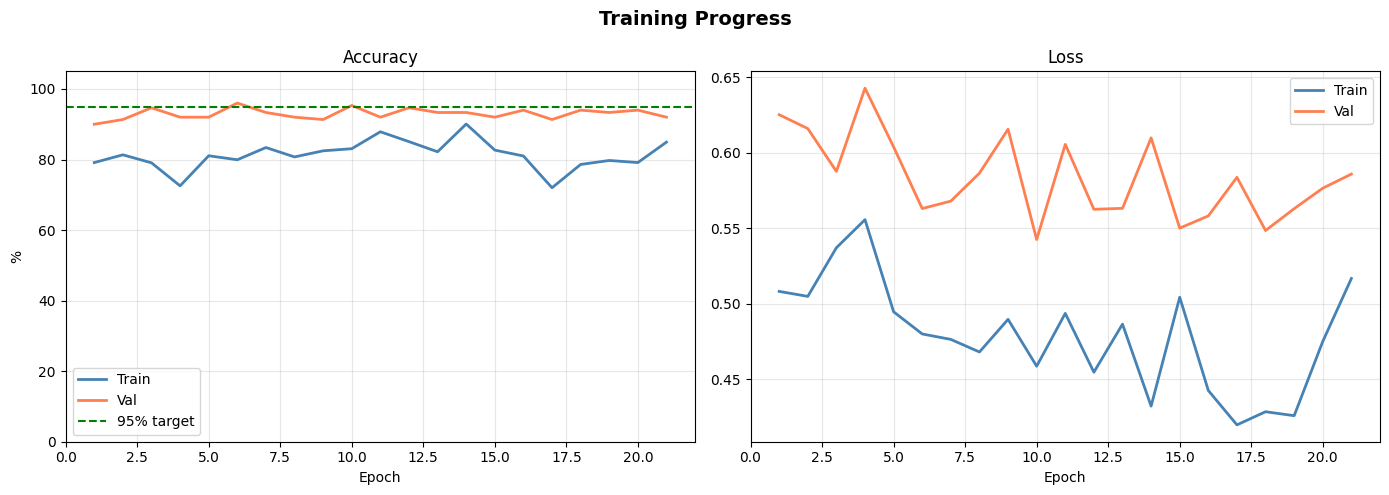

In [27]:
ep = range(1, len(train_accs)+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(ep, [a*100 for a in train_accs], label='Train', color='steelblue', lw=2)
ax1.plot(ep, [a*100 for a in val_accs],   label='Val',   color='coral',     lw=2)
ax1.axhline(95, color='green', ls='--', lw=1.5, label='95% target')
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='%', ylim=(0,105))
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, train_losses, label='Train', color='steelblue', lw=2)
ax2.plot(ep, val_losses,   label='Val',   color='coral',     lw=2)
ax2.set(title='Loss', xlabel='Epoch'); ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle('Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Final evaluation on test set


In [25]:
model.load_state_dict(torch.load(BEST_PATH, map_location=device))
model.eval()

all_preds, all_true = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_true.extend(lbls.tolist())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
accuracy  = (all_preds == all_true).mean()

print(f'Best val accuracy (during training) : {best_val_acc:.1%}')
print(f'Final test accuracy (unseen images)  : {accuracy:.1%}')
print()
print('Target Acheived' if accuracy >= 0.95 else 'Accuracy is below 95% ')
print(classification_report(all_true, all_preds,
      target_names=[c.replace('_',' ') for c in Selected_Categories]))

Best val accuracy (during training) : 96.0%
Final test accuracy (unseen images)  : 98.0%

Target Acheived

                     precision    recall  f1-score   support

   chocolate mousse       1.00      0.90      0.95        10
  hot and sour soup       1.00      1.00      1.00        10
            waffles       0.91      1.00      0.95        10
spaghetti carbonara       1.00      1.00      1.00        10
            edamame       1.00      1.00      1.00        10

           accuracy                           0.98        50
          macro avg       0.98      0.98      0.98        50
       weighted avg       0.98      0.98      0.98        50



## Step 11 — Confusion matrix

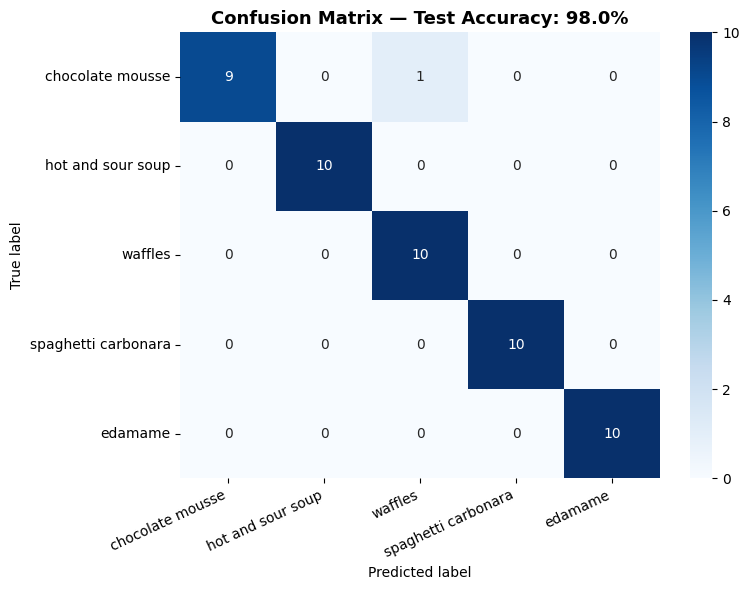

In [33]:
matrix     = confusion_matrix(all_true, all_preds)
labels = [c.replace('_',' ') for c in Selected_Categories]
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix — Test Accuracy: {accuracy:.1%}', fontsize=13, fontweight='bold')
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Save and download results

In [35]:
results = {
    'final_test_accuracy':  float(round(accuracy, 4)),
    'best_val_accuracy':    float(round(best_val_acc, 4)),
    'target_95_met':        bool(accuracy >= 0.95),
    'labeled_images':       100,
    'images_per_class':     20,
    'effective_samples_per_epoch': len(train_ds),
    'model':                'EfficientNet-B2 (ImageNet pretrained)',
    'classes':              Selected_Categories,
    'techniques': [
        'Transfer learning',
        'Selective layer freezing',
        'Heavy augmentation',
        'Repeat sampling',
        'Mixup augmentation',
        'Label smoothing + cosine LR schedule + gradient clipping',
    ]
}

with open('/content/results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

with zipfile.ZipFile('/content/FMCG_project.zip', 'w') as zf:
    for fname in ['training_curves.png',
                  'confusion_matrix.png', 'results.json']:
        path = f'/content/{fname}'
        if os.path.exists(path):
            zf.write(path, fname)
            print(f'Added: {fname}')

print('\nDownload FMCG_project.zip from the Files panel')

{
  "final_test_accuracy": 0.98,
  "best_val_accuracy": 0.96,
  "target_95_met": true,
  "labeled_images": 100,
  "images_per_class": 20,
  "effective_samples_per_epoch": 1500,
  "model": "EfficientNet-B2 (ImageNet pretrained)",
  "classes": [
    "chocolate_mousse",
    "hot_and_sour_soup",
    "waffles",
    "spaghetti_carbonara",
    "edamame"
  ],
  "techniques": [
    "Transfer learning",
    "Selective layer freezing",
    "Heavy augmentation",
    "Repeat sampling",
    "Mixup augmentation",
    "Label smoothing + cosine LR schedule + gradient clipping"
  ]
}
Added: training_curves.png
Added: confusion_matrix.png
Added: results.json

Download FMCG_project.zip from the Files panel
